# 62 — All Regression Experiments: AUB-only vs AUB+Peers

Systematic comparison of **all regression approaches** across two training scenarios:

| Scenario | Train set | Test sets |
|----------|-----------|----------|
| **A** | AUB-only (2015–2017) | AUB-only (2018–2020) |
| **B** | AUB + Peers (2015–2017) | AUB-only (2018–2020) |
| **C** | AUB + Peers (2015–2017) | All-unis (2018–2020) |

**Models tested:** Linear Regression, Ridge, Lasso, ElasticNet, Random Forest, XGBoost, LightGBM  
**Bonus:** Quantile regression (q10/q50/q90), temporal CV, regression-as-classifier  
**Target:** log1p(Citations) → evaluated in log-space (RMSE, MAE, R², Spearman) and as classifier (F1, AUC)

In [1]:
import sys, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, f1_score, precision_score, recall_score, classification_report
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

PROJECT_ROOT = Path('../../').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH    = PROJECT_ROOT / 'data' / 'processed' / 'all_unis_cleaned.pkl'
FEATURES_DIR = PROJECT_ROOT / 'data' / 'features'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE   = 42
TRAIN_YEARS    = [2015, 2016, 2017]
TEST_YEARS     = [2018, 2019, 2020]
TFIDF_MAX_FEAT = 5000

print('Imports OK')
print(f'Project root: {PROJECT_ROOT}')

Imports OK
Project root: C:\Users\Mario.Chartouni\capstone


## 1. Load Data & Build Splits

In [2]:
df = pd.read_pickle(DATA_PATH)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
print('Institutions:', df['institution'].value_counts().to_dict() if 'institution' in df.columns else 'no institution col')

# Identify AUB rows
inst_col = 'institution' if 'institution' in df.columns else 'Institution'
aub_mask = df[inst_col].str.upper().str.contains('AUB|BEIRUT', na=False)

# --- Scenario A & B/C splits ---
# Scenario A: AUB-only train, AUB-only test
df_aub = df[aub_mask].copy()
df_train_aub = df_aub[df_aub['Year'].isin(TRAIN_YEARS)].dropna(subset=['Abstract','Citations']).copy()
df_test_aub  = df_aub[df_aub['Year'].isin(TEST_YEARS)].dropna(subset=['Abstract','Citations']).copy()

# Scenario B/C: Merged train, AUB-only & all-unis test
df_train_all = df[df['Year'].isin(TRAIN_YEARS)].dropna(subset=['Abstract','Citations']).copy()
df_test_all  = df[df['Year'].isin(TEST_YEARS)].dropna(subset=['Abstract','Citations']).copy()
# AUB-only test from the all-unis test set
df_test_aub_from_all = df_test_all[df_test_all[inst_col].str.upper().str.contains('AUB|BEIRUT', na=False)].copy()

print(f'\nScenario A — Train (AUB): {len(df_train_aub):,} | Test (AUB): {len(df_test_aub):,}')
print(f'Scenario B/C — Train (merged): {len(df_train_all):,} | Test (all): {len(df_test_all):,} | Test (AUB): {len(df_test_aub_from_all):,}')

# p75 citation thresholds (on each training set)
thr_A   = df_train_aub['Citations'].quantile(0.75)
thr_BC  = df_train_all['Citations'].quantile(0.75)
print(f'\np75 threshold — Scenario A: {thr_A:.0f} | Scenario B/C: {thr_BC:.0f}')

Loaded 39,391 rows × 69 columns
Institutions: {'AUB': 14832, 'Lehigh': 9848, 'Marquette': 8403, 'Villanova': 6308}

Scenario A — Train (AUB): 2,545 | Test (AUB): 3,573
Scenario B/C — Train (merged): 6,255 | Test (all): 8,871 | Test (AUB): 3,573

p75 threshold — Scenario A: 38 | Scenario B/C: 39


## 2. Feature Engineering Pipeline

Consistent feature construction for both scenarios. We fit TF-IDF and venue stats on each scenario's training set independently.

In [3]:
def preprocess_text(text):
    if pd.isna(text): return ''
    return str(text).lower()


def build_tfidf_features(df_tr, dfs_te, max_features=TFIDF_MAX_FEAT):
    """Fit TF-IDF on training, transform all test sets."""
    tfidf = TfidfVectorizer(
        max_features=max_features, ngram_range=(1, 2),
        min_df=5, max_df=0.80, stop_words='english', sublinear_tf=True
    )
    abs_tr = df_tr['Abstract'].apply(preprocess_text)
    tfidf.fit(abs_tr)
    tr_feat = pd.DataFrame.sparse.from_spmatrix(
        tfidf.transform(abs_tr),
        index=df_tr.index,
        columns=[f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
    )
    te_feats = []
    for df_te in dfs_te:
        abs_te = df_te['Abstract'].apply(preprocess_text)
        te_feats.append(pd.DataFrame.sparse.from_spmatrix(
            tfidf.transform(abs_te),
            index=df_te.index,
            columns=[f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        ))
    return tr_feat, te_feats


def build_venue_features(df_):
    vf = pd.DataFrame(index=df_.index)
    col_map = {
        'snip':                 'SNIP (publication year)',
        'snip_percentile':      'SNIP percentile (publication year) *',
        'citescore':            'CiteScore (publication year)',
        'citescore_percentile': 'CiteScore percentile (publication year) *',
        'sjr':                  'SJR (publication year)',
        'sjr_percentile':       'SJR percentile (publication year) *',
    }
    for feat, col in col_map.items():
        vf[feat] = pd.to_numeric(df_.get(col, pd.Series(np.nan, index=df_.index)), errors='coerce')
    vf['topic_prominence'] = pd.to_numeric(
        df_.get('Topic Prominence Percentile', pd.Series(np.nan, index=df_.index)), errors='coerce'
    )
    vf['topic_cluster_prominence'] = pd.to_numeric(
        df_.get('Topic Cluster Prominence Percentile', pd.Series(np.nan, index=df_.index)), errors='coerce'
    )
    vf['avg_venue_percentile'] = vf[['snip_percentile','citescore_percentile','sjr_percentile']].mean(axis=1)
    vf['is_top_journal']       = (vf['avg_venue_percentile'] >= 75).astype(float)
    return vf.fillna(vf.median(numeric_only=True))


def build_author_features(df_):
    af = pd.DataFrame(index=df_.index)
    for feat, col in [
        ('num_authors',      'Number of Authors'),
        ('num_institutions', 'Number of Institutions'),
        ('num_countries',    'Number of Countries/Regions'),
    ]:
        af[feat] = pd.to_numeric(df_.get(col, pd.Series(np.nan, index=df_.index)), errors='coerce')
    af['is_international_collab'] = (af['num_countries'] > 1).astype(float)
    af['is_multi_inst']           = (af['num_institutions'] > 1).astype(float)
    return af.fillna(af.median(numeric_only=True))


def build_metadata_features(df_):
    mf = pd.DataFrame(index=df_.index)
    oa_col = 'Open Access' if 'Open Access' in df_.columns else 'is_open_access'
    mf['is_open_access'] = df_.get(oa_col, pd.Series(0, index=df_.index)).notna().astype(float)
    pub_type = df_.get('Publication Type', pd.Series('', index=df_.index)).fillna('').str.lower()
    mf['is_article']    = pub_type.str.contains('article').astype(float)
    mf['is_review']     = pub_type.str.contains('review').astype(float)
    mf['is_conference'] = pub_type.str.contains('conference|proceedings').astype(float)
    mf['pub_year']      = pd.to_numeric(df_.get('Year', pd.Series(2015, index=df_.index)), errors='coerce').fillna(2015)
    return mf


def build_interaction_features(vf, af):
    ix = pd.DataFrame(index=vf.index)
    ix['top_journal_x_intl_collab']    = vf['is_top_journal']       * af['is_international_collab']
    ix['venue_pct_x_num_authors']      = vf['avg_venue_percentile'] * af['num_authors']
    ix['venue_pct_x_num_institutions'] = vf['avg_venue_percentile'] * af['num_institutions']
    ix['snip_x_num_authors']           = vf['snip']                 * af['num_authors']
    return ix


def build_numeric_features(df_):
    """Venue + author + metadata + interaction features (no TF-IDF)."""
    vf = build_venue_features(df_)
    af = build_author_features(df_)
    mf = build_metadata_features(df_)
    ix = build_interaction_features(vf, af)
    return pd.concat([vf, af, mf, ix], axis=1)


def drop_year_tokens(X):
    year_cols = [c for c in X.columns if re.match(r'tfidf_\d{4}$', str(c))]
    return X.drop(columns=year_cols, errors='ignore')


def assemble_features(df_tr, dfs_te):
    """Return (X_train, [X_test_1, X_test_2, ...]) as dense float32 DataFrames."""
    text_tr, text_tes = build_tfidf_features(df_tr, dfs_te)
    
    num_tr   = build_numeric_features(df_tr)
    num_tes  = [build_numeric_features(d) for d in dfs_te]

    X_tr  = drop_year_tokens(pd.concat([text_tr, num_tr], axis=1))
    X_tes = [drop_year_tokens(pd.concat([tt, nn], axis=1)) for tt, nn in zip(text_tes, num_tes)]

    # Align test columns to training
    for i, X_te in enumerate(X_tes):
        missing = set(X_tr.columns) - set(X_te.columns)
        extra   = set(X_te.columns) - set(X_tr.columns)
        for c in missing:
            X_te[c] = 0
        X_tes[i] = X_te[X_tr.columns]

    return X_tr.fillna(0).astype('float32'), [x.fillna(0).astype('float32') for x in X_tes]


print('Feature functions defined.')

Feature functions defined.


In [4]:
# --- Build features for Scenario A (AUB-only) ---
print('Building Scenario A features (AUB-only train/test)...')
X_train_A, [X_test_A] = assemble_features(df_train_aub, [df_test_aub])
y_train_A = np.log1p(df_train_aub['Citations'].clip(lower=0).values)
y_test_A  = np.log1p(df_test_aub['Citations'].clip(lower=0).values)
y_test_A_cls = (df_test_aub['Citations'].values >= thr_A).astype(int)
print(f'  X_train_A: {X_train_A.shape} | X_test_A: {X_test_A.shape}')

# --- Build features for Scenarios B & C (merged train) ---
print('Building Scenario B/C features (merged train, AUB+all test)...')
X_train_BC, [X_test_B, X_test_C] = assemble_features(
    df_train_all, [df_test_aub_from_all, df_test_all]
)
y_train_BC  = np.log1p(df_train_all['Citations'].clip(lower=0).values)
y_test_B    = np.log1p(df_test_aub_from_all['Citations'].clip(lower=0).values)
y_test_C    = np.log1p(df_test_all['Citations'].clip(lower=0).values)
y_test_B_cls = (df_test_aub_from_all['Citations'].values >= thr_BC).astype(int)
y_test_C_cls = (df_test_all['Citations'].values >= thr_BC).astype(int)
print(f'  X_train_BC: {X_train_BC.shape} | X_test_B: {X_test_B.shape} | X_test_C: {X_test_C.shape}')

print(f'\ny_train_A range: [{y_train_A.min():.2f}, {y_train_A.max():.2f}]')
print(f'y_train_BC range: [{y_train_BC.min():.2f}, {y_train_BC.max():.2f}]')
print(f'\nClass balance — Scenario A test:  {y_test_A_cls.mean():.1%} high-impact')
print(f'Class balance — Scenario B test:  {y_test_B_cls.mean():.1%} high-impact')
print(f'Class balance — Scenario C test:  {y_test_C_cls.mean():.1%} high-impact')

Building Scenario A features (AUB-only train/test)...
  X_train_A: (2545, 5004) | X_test_A: (3573, 5004)
Building Scenario B/C features (merged train, AUB+all test)...
  X_train_BC: (6255, 5005) | X_test_B: (3573, 5005) | X_test_C: (8871, 5005)

y_train_A range: [0.00, 8.73]
y_train_BC range: [0.00, 8.73]

Class balance — Scenario A test:  19.3% high-impact
Class balance — Scenario B test:  18.6% high-impact
Class balance — Scenario C test:  19.2% high-impact


## 3. Define Models & Evaluation Helpers

In [5]:
POINT_MODELS = {
    'Ridge':          Ridge(alpha=1.0),
    'Lasso':          Pipeline([('scaler', StandardScaler(with_mean=False)), ('lasso', Lasso(alpha=0.01, max_iter=2000))]),
    'ElasticNet':     Pipeline([('scaler', StandardScaler(with_mean=False)), ('en', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=2000))]),
    'Random Forest':  RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':        XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8,
                                   colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM':       LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=63,
                                    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                                    reg_alpha=0.1, reg_lambda=0.1, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

print('Models:', list(POINT_MODELS.keys()))


def reg_metrics(y_true_log, y_pred_log):
    """Return dict of regression metrics (log-space and raw-space)."""
    rmse   = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae    = mean_absolute_error(y_true_log, y_pred_log)
    r2     = r2_score(y_true_log, y_pred_log)
    rho    = spearmanr(y_true_log, y_pred_log).statistic
    mae_r  = mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))
    r2_r   = r2_score(np.expm1(y_true_log), np.expm1(y_pred_log))
    return dict(rmse=rmse, mae=mae, r2=r2, spearman=rho, mae_raw=mae_r, r2_raw=r2_r)


def best_cls_threshold(y_true_log, y_pred_log, y_true_cls, n_thresh=200):
    """Sweep thresholds on log-pred to maximise F1. Returns (f1, auc, precision, recall, threshold)."""
    thresholds = np.linspace(y_pred_log.min(), y_pred_log.max(), n_thresh)
    best = {'f1': 0.0, 'thr': thresholds[0]}
    for t in thresholds:
        pred_cls = (y_pred_log >= t).astype(int)
        f1 = f1_score(y_true_cls, pred_cls, zero_division=0)
        if f1 > best['f1']:
            best.update({'f1': f1, 'thr': t})
    pred_cls = (y_pred_log >= best['thr']).astype(int)
    auc  = roc_auc_score(y_true_cls, y_pred_log) if len(np.unique(y_true_cls)) > 1 else 0.0
    prec = precision_score(y_true_cls, pred_cls, zero_division=0)
    rec  = recall_score(y_true_cls, pred_cls, zero_division=0)
    return dict(f1=best['f1'], auc=auc, precision=prec, recall=rec, threshold=best['thr'])


def run_scenario(name, X_tr, y_tr, scenarios, verbose=True):
    """
    Train all POINT_MODELS on (X_tr, y_tr).
    scenarios: list of (label, X_te, y_te_log, y_te_cls)
    Returns: results dict keyed by (model_name, scenario_label)
    """
    results = {}
    for mname, model in POINT_MODELS.items():
        if verbose: print(f'  Training {mname}...', flush=True)
        import copy
        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        for slabel, X_te, y_te_log, y_te_cls in scenarios:
            y_pred = m.predict(X_te)
            reg = reg_metrics(y_te_log, y_pred)
            cls = best_cls_threshold(y_te_log, y_pred, y_te_cls)
            results[(mname, slabel)] = {**reg, **cls}
    return results


print('Helpers defined.')

Models: ['Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'XGBoost', 'LightGBM']
Helpers defined.


## 4. Scenario A — AUB-only Train & Test

In [6]:
print('=== SCENARIO A: AUB-only train → AUB-only test ===')
results_A = run_scenario(
    'A',
    X_train_A, y_train_A,
    scenarios=[('A_test_aub', X_test_A, y_test_A, y_test_A_cls)]
)
print('Done.')

=== SCENARIO A: AUB-only train → AUB-only test ===
  Training Ridge...
  Training Lasso...
  Training ElasticNet...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...
Done.


In [7]:
# Pretty print Scenario A results
rows_A = []
for (mname, slabel), m in results_A.items():
    rows_A.append({'model': mname, **m})
df_A = pd.DataFrame(rows_A).set_index('model')
display_cols = ['rmse','mae','r2','spearman','mae_raw','r2_raw','f1','auc','precision','recall']
print('\nScenario A — AUB-only (test 2018-2020):')
print(df_A[display_cols].round(4).to_string())

# Highlight best per metric
print(f'\nBest Spearman : {df_A["spearman"].idxmax()}  ({df_A["spearman"].max():.4f})')
print(f'Best R²       : {df_A["r2"].idxmax()}  ({df_A["r2"].max():.4f})')
print(f'Best F1 (cls) : {df_A["f1"].idxmax()}  ({df_A["f1"].max():.4f})')
print(f'Best AUC      : {df_A["auc"].idxmax()}  ({df_A["auc"].max():.4f})')


Scenario A — AUB-only (test 2018-2020):
                 rmse     mae      r2  spearman       mae_raw        r2_raw      f1     auc  precision  recall
model                                                                                                         
Ridge          1.0221  0.7636  0.3053    0.5921  1.339127e+06 -3.155076e+10  0.5055  0.7963     0.3962  0.6981
Lasso          1.1123  0.8513  0.1773    0.5339  3.981666e+05 -2.789552e+09  0.4639  0.7671     0.4059  0.5414
ElasticNet     1.1974  0.9297  0.0467    0.4720  2.951417e+05 -1.532618e+09  0.4377  0.7341     0.3557  0.5689
Random Forest  0.9751  0.7586  0.3677    0.6140  3.087070e+01  1.990000e-02  0.5266  0.8071     0.4379  0.6604
XGBoost        0.9736  0.7605  0.3698    0.6206  3.086570e+01  2.480000e-02  0.5270  0.8108     0.4493  0.6372
LightGBM       0.9760  0.7639  0.3666    0.6147  3.132680e+01  3.820000e-02  0.5258  0.8076     0.4483  0.6357

Best Spearman : XGBoost  (0.6206)
Best R²       : XGBoost  (0.3698)
Be

## 5. Scenarios B & C — Merged (AUB+Peers) Train

In [8]:
print('=== SCENARIOS B & C: Merged train → AUB-only test (B) & All-unis test (C) ===')
results_BC = run_scenario(
    'BC',
    X_train_BC, y_train_BC,
    scenarios=[
        ('B_test_aub', X_test_B, y_test_B, y_test_B_cls),
        ('C_test_all', X_test_C, y_test_C, y_test_C_cls),
    ]
)
print('Done.')

=== SCENARIOS B & C: Merged train → AUB-only test (B) & All-unis test (C) ===
  Training Ridge...
  Training Lasso...
  Training ElasticNet...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...
Done.


In [9]:
# Scenario B results (merged model → AUB test)
rows_B = [{'model': mname, **m} for (mname, slabel), m in results_BC.items() if slabel == 'B_test_aub']
df_B = pd.DataFrame(rows_B).set_index('model')
print('Scenario B — Merged train → AUB-only test:')
print(df_B[display_cols].round(4).to_string())
print(f'\nBest Spearman : {df_B["spearman"].idxmax()}  ({df_B["spearman"].max():.4f})')
print(f'Best F1 (cls) : {df_B["f1"].idxmax()}  ({df_B["f1"].max():.4f})')

# Scenario C results (merged model → all-unis test)
rows_C = [{'model': mname, **m} for (mname, slabel), m in results_BC.items() if slabel == 'C_test_all']
df_C = pd.DataFrame(rows_C).set_index('model')
print('\nScenario C — Merged train → All-unis test:')
print(df_C[display_cols].round(4).to_string())
print(f'\nBest Spearman : {df_C["spearman"].idxmax()}  ({df_C["spearman"].max():.4f})')
print(f'Best F1 (cls) : {df_C["f1"].idxmax()}  ({df_C["f1"].max():.4f})')

Scenario B — Merged train → AUB-only test:
                 rmse     mae      r2  spearman       mae_raw        r2_raw      f1     auc  precision  recall
model                                                                                                         
Ridge          1.0203  0.7692  0.3078    0.6008  2.663997e+06 -1.248943e+11  0.5186  0.8067     0.4264  0.6617
Lasso          1.0184  0.7718  0.3103    0.6008  6.554374e+05 -7.559714e+09  0.5241  0.8090     0.4264  0.6797
ElasticNet     1.0741  0.8238  0.2328    0.5530  2.016861e+05 -7.156323e+08  0.4882  0.7827     0.4027  0.6195
Random Forest  0.9901  0.7725  0.3482    0.6130  3.104600e+01  2.190000e-02  0.5099  0.8105     0.4971  0.5233
XGBoost        0.9704  0.7551  0.3738    0.6327  3.086430e+01  3.120000e-02  0.5515  0.8303     0.4895  0.6316
LightGBM       0.9831  0.7672  0.3574    0.6181  3.132530e+01  3.340000e-02  0.5364  0.8243     0.4860  0.5985

Best Spearman : XGBoost  (0.6327)
Best F1 (cls) : XGBoost  (0.5515)


## 6. Head-to-Head: AUB-only vs Merged (Scenario A vs B)

Same test set (AUB 2018–2020). Does adding peer university training data help or hurt?

In [10]:
compare = pd.DataFrame({
    'Spearman_A':  df_A['spearman'],
    'Spearman_B':  df_B['spearman'],
    'Δ_Spearman':  df_B['spearman'] - df_A['spearman'],
    'R2_A':        df_A['r2'],
    'R2_B':        df_B['r2'],
    'Δ_R2':        df_B['r2'] - df_A['r2'],
    'F1_A':        df_A['f1'],
    'F1_B':        df_B['f1'],
    'Δ_F1':        df_B['f1'] - df_A['f1'],
    'AUC_A':       df_A['auc'],
    'AUC_B':       df_B['auc'],
    'Δ_AUC':       df_B['auc'] - df_A['auc'],
})
print('Head-to-head: Scenario A (AUB-only) vs Scenario B (merged → AUB test)')
print('Positive Δ = merged data helps, Negative Δ = merged data hurts')
print()
print(compare.round(4).to_string())

print(f'\nModels where merged HELPS Spearman: {(compare["Δ_Spearman"] > 0).sum()}/{len(compare)}')
print(f'Models where merged HELPS F1:       {(compare["Δ_F1"] > 0).sum()}/{len(compare)}')
print(f'Models where merged HELPS AUC:      {(compare["Δ_AUC"] > 0).sum()}/{len(compare)}')

Head-to-head: Scenario A (AUB-only) vs Scenario B (merged → AUB test)
Positive Δ = merged data helps, Negative Δ = merged data hurts

               Spearman_A  Spearman_B  Δ_Spearman    R2_A    R2_B    Δ_R2    F1_A    F1_B    Δ_F1   AUC_A   AUC_B   Δ_AUC
model                                                                                                                    
Ridge              0.5921      0.6008      0.0087  0.3053  0.3078  0.0025  0.5055  0.5186  0.0130  0.7963  0.8067  0.0104
Lasso              0.5339      0.6008      0.0669  0.1773  0.3103  0.1330  0.4639  0.5241  0.0601  0.7671  0.8090  0.0418
ElasticNet         0.4720      0.5530      0.0809  0.0467  0.2328  0.1862  0.4377  0.4882  0.0504  0.7341  0.7827  0.0486
Random Forest      0.6140      0.6130     -0.0010  0.3677  0.3482 -0.0196  0.5266  0.5099 -0.0167  0.8071  0.8105  0.0034
XGBoost            0.6206      0.6327      0.0121  0.3698  0.3738  0.0040  0.5270  0.5515  0.0245  0.8108  0.8303  0.0195
LightGBM    

## 7. Visualisation — Regression Metrics Across All Scenarios

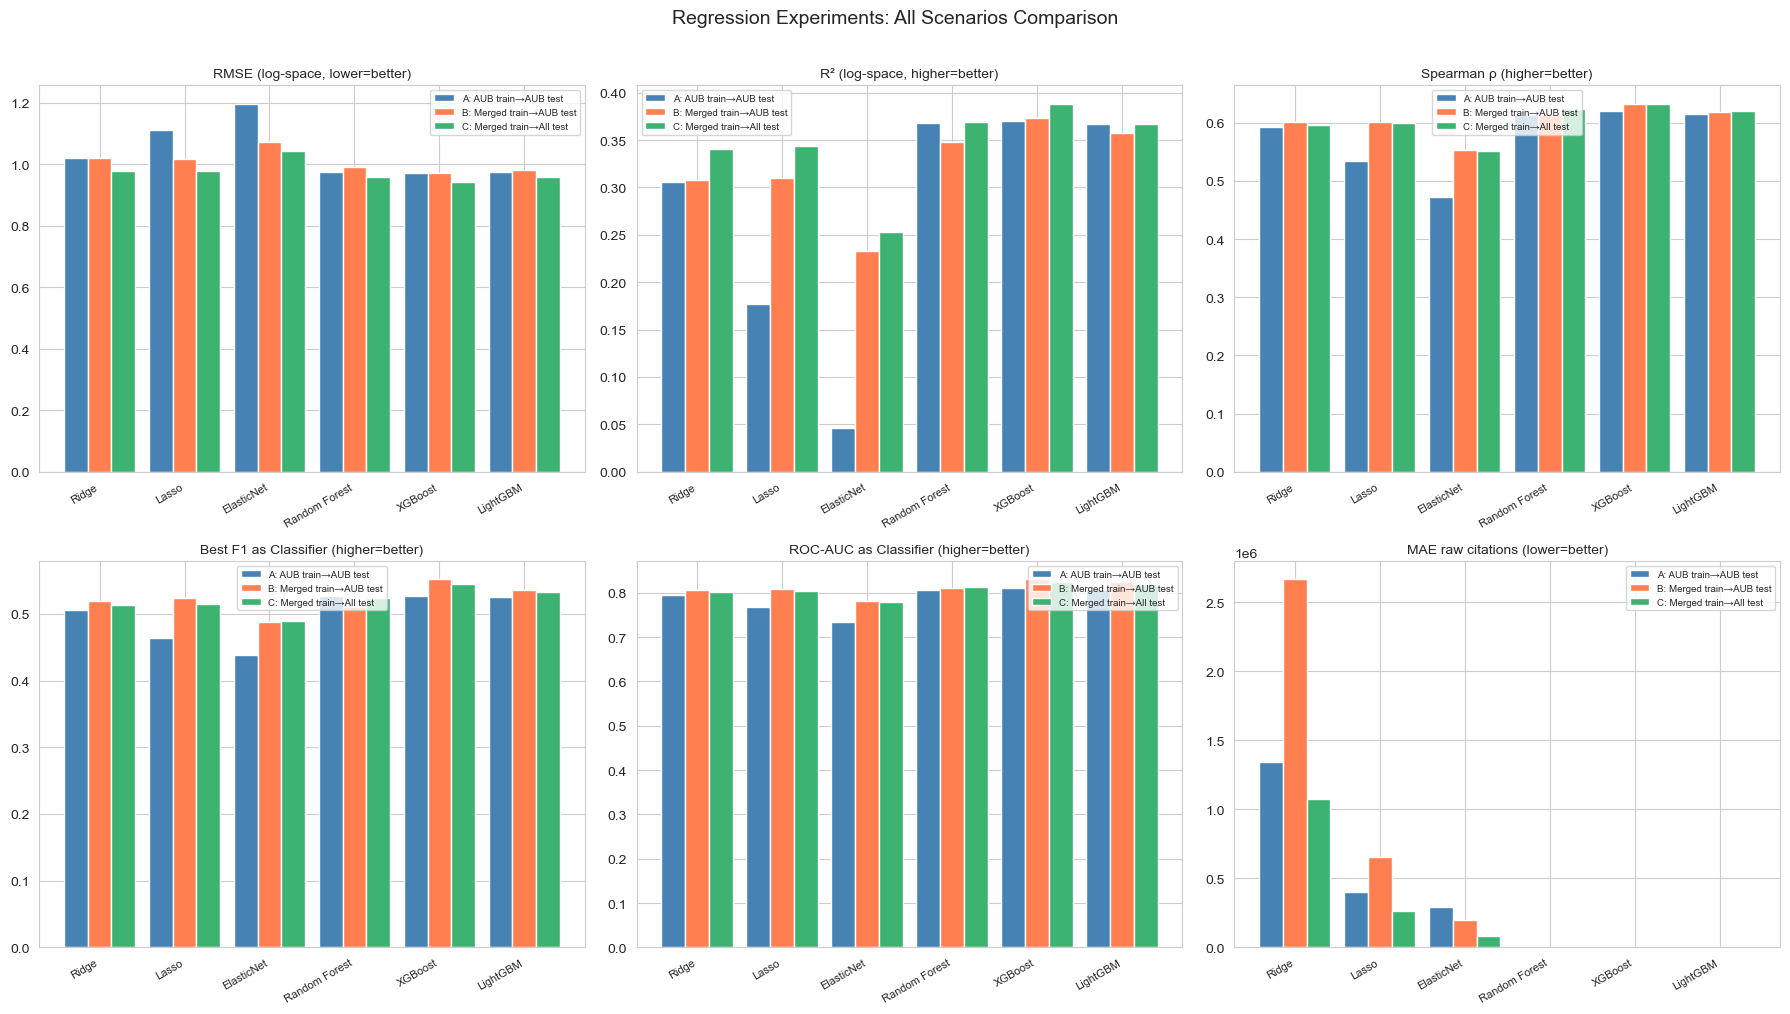

Saved: reports/nb62_regression_comparison.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = [
    ('rmse',     'RMSE (log-space, lower=better)'),
    ('r2',       'R² (log-space, higher=better)'),
    ('spearman', 'Spearman ρ (higher=better)'),
    ('f1',       'Best F1 as Classifier (higher=better)'),
    ('auc',      'ROC-AUC as Classifier (higher=better)'),
    ('mae_raw',  'MAE raw citations (lower=better)'),
]

models = df_A.index.tolist()
x = np.arange(len(models))
width = 0.28

for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
    v_A = df_A[metric].values
    v_B = df_B[metric].values
    v_C = df_C[metric].values

    ax.bar(x - width, v_A, width, label='A: AUB train→AUB test', color='steelblue')
    ax.bar(x,          v_B, width, label='B: Merged train→AUB test', color='coral')
    ax.bar(x + width,  v_C, width, label='C: Merged train→All test', color='mediumseagreen')

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Regression Experiments: All Scenarios Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'nb62_regression_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/nb62_regression_comparison.png')

## 8. Temporal Cross-Validation (Honest Estimates)

Standard `KFold(shuffle=True)` leaks future information. `TimeSeriesSplit` gives honest CV estimates by always predicting forward in time.

In [12]:
import copy
from sklearn.metrics import make_scorer

def spearman_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred).statistic

spearman_sc = make_scorer(spearman_scorer)

temporal_cv_results = {}

for scenario_name, X_tr, y_tr, df_tr in [
    ('A_AUB_only',  X_train_A,  y_train_A,  df_train_aub),
    ('BC_Merged',   X_train_BC, y_train_BC, df_train_all),
]:
    print(f'\n--- Temporal CV: {scenario_name} ---')
    sort_idx = df_tr.sort_values('Year').index
    X_sorted = X_tr.loc[sort_idx]
    y_sorted = y_tr[df_tr.index.get_indexer(sort_idx)]

    tscv = TimeSeriesSplit(n_splits=3)
    scenario_cv = {}

    for mname, model in POINT_MODELS.items():
        m = copy.deepcopy(model)
        cv_res = cross_validate(
            m, X_sorted, y_sorted,
            cv=tscv,
            scoring={'mse': 'neg_mean_squared_error', 'r2': 'r2', 'spearman': spearman_sc},
            n_jobs=1, error_score='raise'
        )
        rmse = np.sqrt(-cv_res['test_mse'].mean())
        r2   = cv_res['test_r2'].mean()
        rho  = cv_res['test_spearman'].mean()
        scenario_cv[mname] = {'temporal_cv_rmse': rmse, 'temporal_cv_r2': r2, 'temporal_cv_spearman': rho}
        print(f'  {mname:20s}  RMSE={rmse:.4f}  R²={r2:.4f}  Spearman={rho:.4f}')

    temporal_cv_results[scenario_name] = scenario_cv

print('\nTemporal CV done.')


--- Temporal CV: A_AUB_only ---
  Ridge                 RMSE=1.1174  R²=0.0395  Spearman=0.5682
  Lasso                 RMSE=1.2243  R²=-0.1297  Spearman=0.4428
  ElasticNet            RMSE=1.2775  R²=-0.2407  Spearman=0.4103
  Random Forest         RMSE=1.1928  R²=-0.1407  Spearman=0.5580
  XGBoost               RMSE=1.1676  R²=-0.0920  Spearman=0.5510
  LightGBM              RMSE=1.1600  R²=-0.0756  Spearman=0.5491

--- Temporal CV: BC_Merged ---
  Ridge                 RMSE=1.1450  R²=0.1719  Spearman=0.5451
  Lasso                 RMSE=1.1275  R²=0.1752  Spearman=0.4916
  ElasticNet            RMSE=1.2339  R²=0.0046  Spearman=0.4363
  Random Forest         RMSE=0.9800  R²=0.3737  Spearman=0.5872
  XGBoost               RMSE=0.9845  R²=0.3682  Spearman=0.5868
  LightGBM              RMSE=1.0065  R²=0.3388  Spearman=0.5603

Temporal CV done.


## 9. Quantile Regression (Prediction Intervals)

Train LightGBM at **q25, q50, q75** (50% interval) and **q10, q50, q90** (80% interval).  
A paper whose interval lies entirely above the high-impact threshold → confident High.  
Entirely below → confident Low. Otherwise → Uncertain.

In [13]:
def train_quantile_models(X_tr, y_tr, quantiles=(0.10, 0.50, 0.90), n_est=500):
    models = {}
    for q in quantiles:
        m = LGBMRegressor(
            objective='quantile', alpha=q,
            n_estimators=n_est, max_depth=6, learning_rate=0.05,
            num_leaves=31, min_child_samples=20,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
        m.fit(X_tr, y_tr)
        models[f'q{int(q*100):02d}'] = m
        print(f'  q{q:.0%} done')
    return models


def evaluate_quantile(qmodels, X_te, y_te_log, y_te_cls, log_threshold, label=''):
    lo_key = sorted(qmodels.keys())[0]
    hi_key = sorted(qmodels.keys())[-1]
    mid_key = sorted(qmodels.keys())[len(qmodels)//2]

    pred_lo  = qmodels[lo_key].predict(X_te)
    pred_mid = qmodels[mid_key].predict(X_te)
    pred_hi  = qmodels[hi_key].predict(X_te)

    conf_high = pred_lo >= log_threshold
    conf_low  = pred_hi <  log_threshold
    uncertain = ~conf_high & ~conf_low

    n = len(y_te_log)
    print(f'\n{label}  (n={n:,})')
    print(f'  Confident HIGH : {conf_high.sum():5d} ({conf_high.mean():.1%})')
    print(f'  Confident LOW  : {conf_low.sum():5d} ({conf_low.mean():.1%})')
    print(f'  Uncertain      : {uncertain.sum():5d} ({uncertain.mean():.1%})')
    print(f'  Interval width : mean={np.mean(pred_hi - pred_lo):.4f}  median={np.median(pred_hi - pred_lo):.4f}')

    # Nominal vs empirical coverage
    coverage = np.mean((y_te_log >= pred_lo) & (y_te_log <= pred_hi))
    print(f'  Coverage (nominal {hi_key[1:]}-{lo_key[1:]} interval): empirical={coverage:.1%}')

    # q50 as classifier
    cls_mid = best_cls_threshold(y_te_log, pred_mid, y_te_cls)
    print(f'  q50 regression-as-classifier: F1={cls_mid["f1"]:.4f}  AUC={cls_mid["auc"]:.4f}')

    # Three-way: confident set only
    definite_mask = conf_high | conf_low
    if definite_mask.sum() > 0:
        pred_3way = conf_high[definite_mask].astype(int)
        true_3way = y_te_cls[definite_mask]
        f1_3 = f1_score(true_3way, pred_3way, zero_division=0)
        prec_3 = precision_score(true_3way, pred_3way, zero_division=0)
        rec_3  = recall_score(true_3way, pred_3way, zero_division=0)
        print(f'  Three-way (confident only): F1={f1_3:.4f}  Prec={prec_3:.4f}  Rec={rec_3:.4f}  coverage={definite_mask.mean():.1%}')

    return {'conf_high': conf_high, 'conf_low': conf_low, 'uncertain': uncertain,
            'pred_lo': pred_lo, 'pred_mid': pred_mid, 'pred_hi': pred_hi,
            'cls_mid': cls_mid}


print('Quantile helpers defined.')

Quantile helpers defined.


In [14]:
log_thr_A  = np.log1p(thr_A)
log_thr_BC = np.log1p(thr_BC)

# --- 80% prediction interval (q10/q50/q90) ---
print('Training quantile models — Scenario A (AUB-only, q10/q50/q90)...')
qm_A_80 = train_quantile_models(X_train_A, y_train_A, quantiles=(0.10, 0.50, 0.90))

print('\nTraining quantile models — Scenario BC (merged, q10/q50/q90)...')
qm_BC_80 = train_quantile_models(X_train_BC, y_train_BC, quantiles=(0.10, 0.50, 0.90))

Training quantile models — Scenario A (AUB-only, q10/q50/q90)...
  q10% done
  q50% done
  q90% done

Training quantile models — Scenario BC (merged, q10/q50/q90)...
  q10% done
  q50% done
  q90% done


In [15]:
print('=== 80% prediction interval (q10/q50/q90) ===')
q_res_A_80  = evaluate_quantile(qm_A_80,  X_test_A,  y_test_A,  y_test_A_cls,  log_thr_A,  'Scenario A  (AUB train → AUB test)')
q_res_B_80  = evaluate_quantile(qm_BC_80, X_test_B,  y_test_B,  y_test_B_cls,  log_thr_BC, 'Scenario B  (Merged train → AUB test)')
q_res_C_80  = evaluate_quantile(qm_BC_80, X_test_C,  y_test_C,  y_test_C_cls,  log_thr_BC, 'Scenario C  (Merged train → All test)')

=== 80% prediction interval (q10/q50/q90) ===

Scenario A  (AUB train → AUB test)  (n=3,573)
  Confident HIGH :     0 (0.0%)
  Confident LOW  :  1273 (35.6%)
  Uncertain      :  2300 (64.4%)
  Interval width : mean=2.0670  median=2.0093
  Coverage (nominal 90-10 interval): empirical=71.3%
  q50 regression-as-classifier: F1=0.5383  AUC=0.8157
  Three-way (confident only): F1=0.0000  Prec=0.0000  Rec=0.0000  coverage=35.6%

Scenario B  (Merged train → AUB test)  (n=3,573)
  Confident HIGH :     0 (0.0%)
  Confident LOW  :   986 (27.6%)
  Uncertain      :  2587 (72.4%)
  Interval width : mean=2.1310  median=2.0909
  Coverage (nominal 90-10 interval): empirical=73.2%
  q50 regression-as-classifier: F1=0.5426  AUC=0.8246
  Three-way (confident only): F1=0.0000  Prec=0.0000  Rec=0.0000  coverage=27.6%

Scenario C  (Merged train → All test)  (n=8,871)
  Confident HIGH :     0 (0.0%)
  Confident LOW  :  2554 (28.8%)
  Uncertain      :  6317 (71.2%)
  Interval width : mean=2.1159  median=2.0846

In [16]:
# --- 50% prediction interval (q25/q50/q75) — tighter intervals, higher coverage requirement ---
print('Training quantile models — Scenario A (AUB-only, q25/q50/q75)...')
qm_A_50 = train_quantile_models(X_train_A, y_train_A, quantiles=(0.25, 0.50, 0.75))

print('\nTraining quantile models — Scenario BC (merged, q25/q50/q75)...')
qm_BC_50 = train_quantile_models(X_train_BC, y_train_BC, quantiles=(0.25, 0.50, 0.75))

print('\n=== 50% prediction interval (q25/q50/q75) ===')
q_res_A_50  = evaluate_quantile(qm_A_50,  X_test_A,  y_test_A,  y_test_A_cls,  log_thr_A,  'Scenario A  (AUB train → AUB test)')
q_res_B_50  = evaluate_quantile(qm_BC_50, X_test_B,  y_test_B,  y_test_B_cls,  log_thr_BC, 'Scenario B  (Merged train → AUB test)')
q_res_C_50  = evaluate_quantile(qm_BC_50, X_test_C,  y_test_C,  y_test_C_cls,  log_thr_BC, 'Scenario C  (Merged train → All test)')

Training quantile models — Scenario A (AUB-only, q25/q50/q75)...
  q25% done
  q50% done
  q75% done

Training quantile models — Scenario BC (merged, q25/q50/q75)...
  q25% done
  q50% done
  q75% done

=== 50% prediction interval (q25/q50/q75) ===

Scenario A  (AUB train → AUB test)  (n=3,573)
  Confident HIGH :   103 (2.9%)
  Confident LOW  :  2336 (65.4%)
  Uncertain      :  1134 (31.7%)
  Interval width : mean=0.9701  median=0.9390
  Coverage (nominal 75-25 interval): empirical=39.5%
  q50 regression-as-classifier: F1=0.5383  AUC=0.8157
  Three-way (confident only): F1=0.4451  Prec=0.7864  Rec=0.3103  coverage=68.3%

Scenario B  (Merged train → AUB test)  (n=3,573)
  Confident HIGH :   139 (3.9%)
  Confident LOW  :  2274 (63.6%)
  Uncertain      :  1160 (32.5%)
  Interval width : mean=1.0126  median=0.9865
  Coverage (nominal 75-25 interval): empirical=41.9%
  q50 regression-as-classifier: F1=0.5426  AUC=0.8246
  Three-way (confident only): F1=0.5261  Prec=0.7626  Rec=0.4015  cover

## 10. Prediction Interval Visualisation

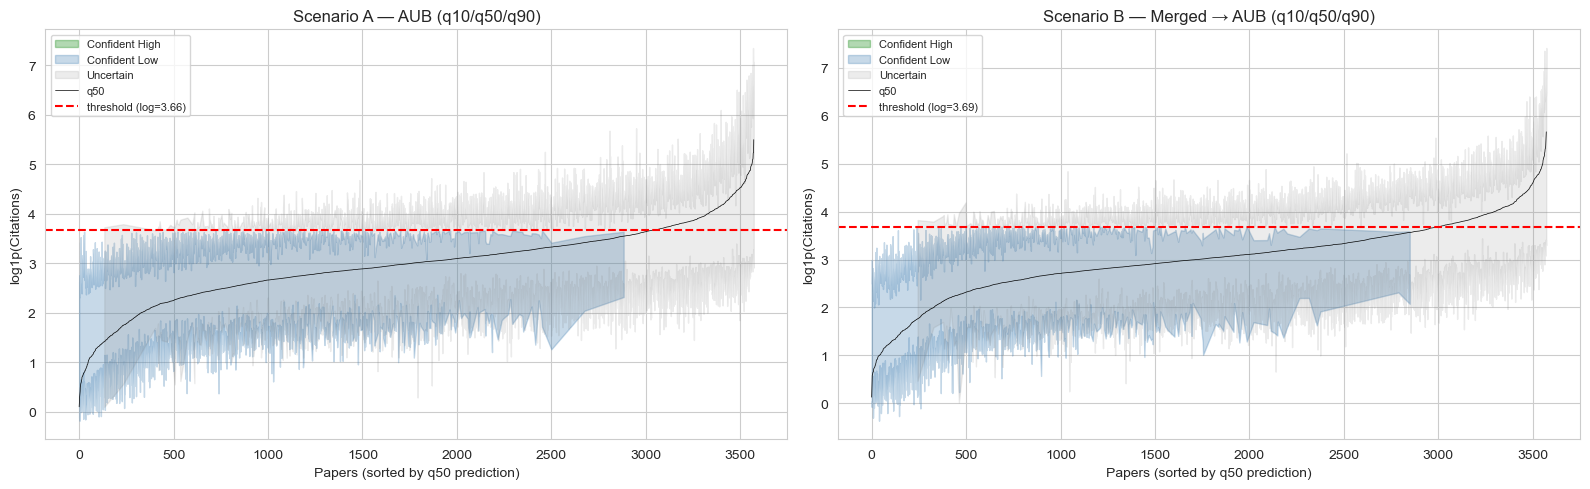

Saved: reports/nb62_quantile_intervals.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (res, log_thr, title) in zip(axes, [
    (q_res_A_80,  log_thr_A,  'Scenario A — AUB (q10/q50/q90)'),
    (q_res_B_80,  log_thr_BC, 'Scenario B — Merged → AUB (q10/q50/q90)'),
]):
    sort_idx = np.argsort(res['pred_mid'])
    x_plot   = np.arange(len(sort_idx))
    ch = res['conf_high'][sort_idx]
    cl = res['conf_low'][sort_idx]
    uc = res['uncertain'][sort_idx]

    # Fill between q10 and q90
    ax.fill_between(x_plot[ch], res['pred_lo'][sort_idx][ch], res['pred_hi'][sort_idx][ch],
                    alpha=0.3, color='green', label='Confident High')
    ax.fill_between(x_plot[cl], res['pred_lo'][sort_idx][cl], res['pred_hi'][sort_idx][cl],
                    alpha=0.3, color='steelblue', label='Confident Low')
    ax.fill_between(x_plot[uc], res['pred_lo'][sort_idx][uc], res['pred_hi'][sort_idx][uc],
                    alpha=0.15, color='gray', label='Uncertain')
    ax.plot(x_plot, res['pred_mid'][sort_idx], 'k-', linewidth=0.5, label='q50')
    ax.axhline(log_thr, color='red', linestyle='--', linewidth=1.5, label=f'threshold (log={log_thr:.2f})')
    ax.set_xlabel('Papers (sorted by q50 prediction)')
    ax.set_ylabel('log1p(Citations)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'nb62_quantile_intervals.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/nb62_quantile_intervals.png')

## 11. Feature Importance: LightGBM (Best Model)

Compare top features between AUB-only and merged training scenarios.

Training LightGBM (Scenario A)...
Training LightGBM (Scenario BC)...


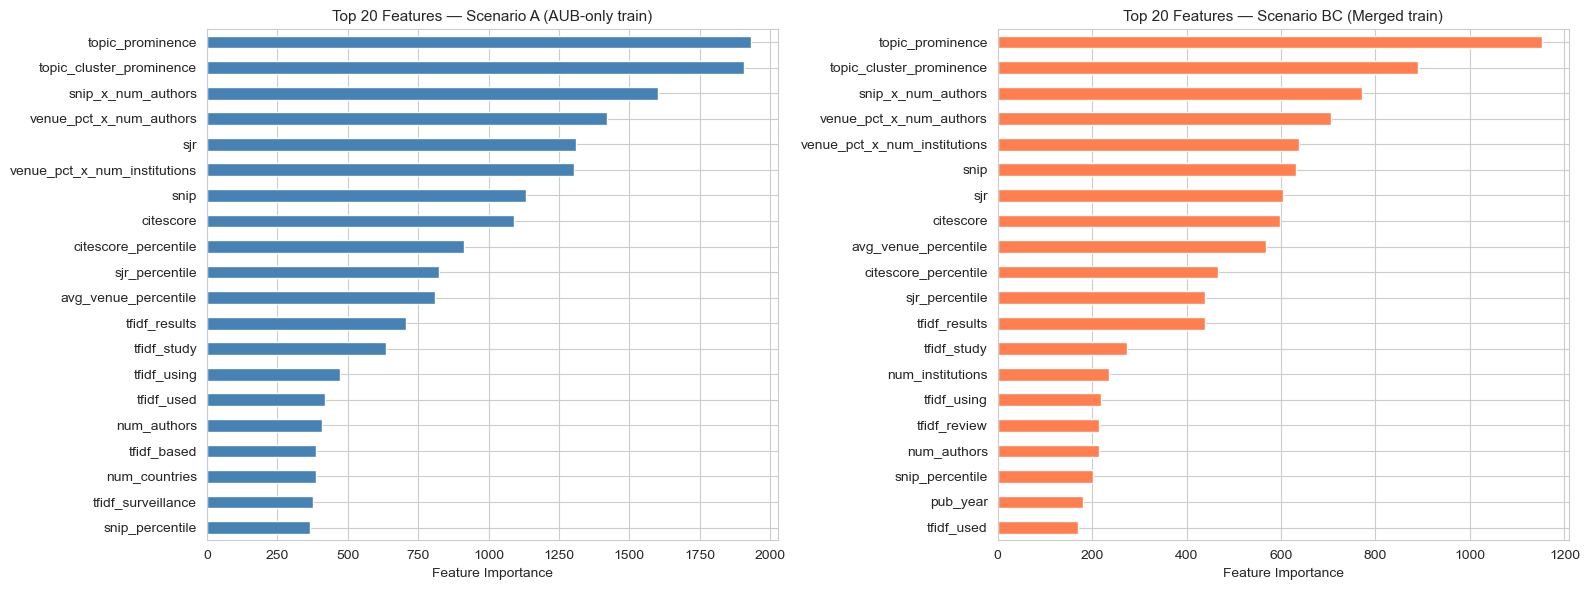

Saved: reports/nb62_feature_importance.png

Features in A top-20 but not BC top-20: {'tfidf_based', 'num_countries', 'tfidf_surveillance'}
Features in BC top-20 but not A top-20: {'num_institutions', 'pub_year', 'tfidf_review'}


In [18]:
import copy

# Re-train LightGBM for both scenarios to get feature importances
lgbm_A  = copy.deepcopy(POINT_MODELS['LightGBM'])
lgbm_BC = copy.deepcopy(POINT_MODELS['LightGBM'])

print('Training LightGBM (Scenario A)...')
lgbm_A.fit(X_train_A, y_train_A)
print('Training LightGBM (Scenario BC)...')
lgbm_BC.fit(X_train_BC, y_train_BC)

imp_A  = pd.Series(lgbm_A.feature_importances_,  index=X_train_A.columns).nlargest(20)
imp_BC = pd.Series(lgbm_BC.feature_importances_, index=X_train_BC.columns).nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
imp_A.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Features — Scenario A (AUB-only train)', fontsize=11)
axes[0].set_xlabel('Feature Importance')

imp_BC.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 20 Features — Scenario BC (Merged train)', fontsize=11)
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'nb62_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/nb62_feature_importance.png')

# Features unique to each top-20
set_A  = set(imp_A.index)
set_BC = set(imp_BC.index)
print(f'\nFeatures in A top-20 but not BC top-20: {set_A - set_BC}')
print(f'Features in BC top-20 but not A top-20: {set_BC - set_A}')

## 12. Regression-to-Classification: Threshold Sweep Visualisation

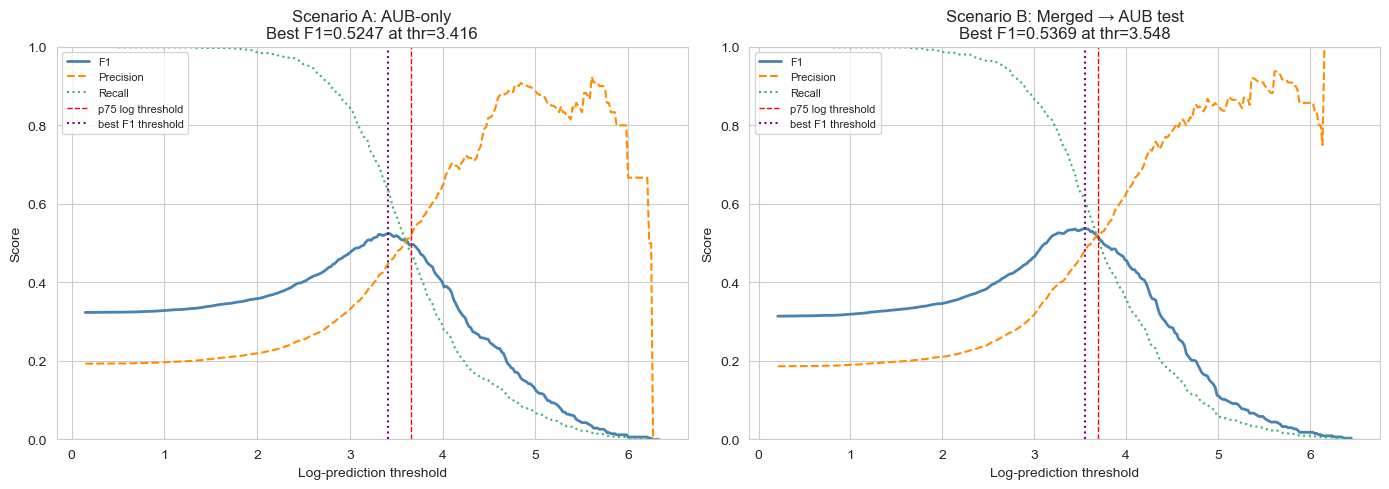

Saved: reports/nb62_threshold_sweep.png


In [19]:
# Show how F1 varies with threshold for the best regression model (LightGBM) in each scenario
y_pred_A  = lgbm_A.predict(X_test_A)
y_pred_B  = lgbm_BC.predict(X_test_B)

def f1_sweep(y_pred, y_true_cls, n=300):
    thresholds = np.linspace(y_pred.min(), y_pred.max(), n)
    f1s = [f1_score(y_true_cls, (y_pred >= t).astype(int), zero_division=0) for t in thresholds]
    precs = [precision_score(y_true_cls, (y_pred >= t).astype(int), zero_division=0) for t in thresholds]
    recs  = [recall_score(y_true_cls, (y_pred >= t).astype(int), zero_division=0) for t in thresholds]
    return thresholds, f1s, precs, recs

thr_A_log  = np.log1p(thr_A)
thr_BC_log = np.log1p(thr_BC)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_pred, y_cls, log_thr, title) in zip(axes, [
    (y_pred_A, y_test_A_cls, thr_A_log,  'Scenario A: AUB-only'),
    (y_pred_B, y_test_B_cls, thr_BC_log, 'Scenario B: Merged → AUB test'),
]):
    thrs, f1s, precs, recs = f1_sweep(y_pred, y_cls)
    ax.plot(thrs, f1s,   label='F1',        color='steelblue',    linewidth=2)
    ax.plot(thrs, precs, label='Precision', color='darkorange',   linewidth=1.5, linestyle='--')
    ax.plot(thrs, recs,  label='Recall',    color='mediumseagreen', linewidth=1.5, linestyle=':')
    ax.axvline(log_thr, color='red', linestyle='--', linewidth=1, label=f'p75 log threshold')
    best_f1_thr = thrs[np.argmax(f1s)]
    ax.axvline(best_f1_thr, color='purple', linestyle=':', linewidth=1.5, label=f'best F1 threshold')
    ax.set_xlabel('Log-prediction threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{title}\nBest F1={max(f1s):.4f} at thr={best_f1_thr:.3f}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'nb62_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/nb62_threshold_sweep.png')

## 13. Final Summary Table

Consolidate all experiment results with the **classification baseline (F1=62.55%)** as reference.

In [20]:
CLASSIFICATION_BASELINE_F1  = 0.6255
CLASSIFICATION_BASELINE_AUC = 0.8104

rows = []

# Point prediction models — Scenario A
for mname, m in df_A.iterrows():
    rows.append({
        'experiment':  f'{mname} (Scenario A: AUB train)',
        'train_data':  'AUB-only',
        'test_data':   'AUB-only',
        'model':       mname,
        'rmse':        m['rmse'],
        'r2':          m['r2'],
        'spearman':    m['spearman'],
        'f1_cls':      m['f1'],
        'auc_cls':     m['auc'],
        'delta_f1':    m['f1'] - CLASSIFICATION_BASELINE_F1,
    })

# Point prediction models — Scenario B (merged → AUB test)
for mname, m in df_B.iterrows():
    rows.append({
        'experiment':  f'{mname} (Scenario B: Merged→AUB)',
        'train_data':  'AUB+Peers',
        'test_data':   'AUB-only',
        'model':       mname,
        'rmse':        m['rmse'],
        'r2':          m['r2'],
        'spearman':    m['spearman'],
        'f1_cls':      m['f1'],
        'auc_cls':     m['auc'],
        'delta_f1':    m['f1'] - CLASSIFICATION_BASELINE_F1,
    })

# Point prediction models — Scenario C (merged → all-unis test)
for mname, m in df_C.iterrows():
    rows.append({
        'experiment':  f'{mname} (Scenario C: Merged→All)',
        'train_data':  'AUB+Peers',
        'test_data':   'All-unis',
        'model':       mname,
        'rmse':        m['rmse'],
        'r2':          m['r2'],
        'spearman':    m['spearman'],
        'f1_cls':      m['f1'],
        'auc_cls':     m['auc'],
        'delta_f1':    m['f1'] - CLASSIFICATION_BASELINE_F1,
    })

# Quantile regression (q50 as classifier)
for scenario_label, res, train_data, test_data in [
    ('A q50 80%-CI (AUB)',           q_res_A_80,  'AUB-only',  'AUB-only'),
    ('B q50 80%-CI (Merged→AUB)',    q_res_B_80,  'AUB+Peers', 'AUB-only'),
    ('C q50 80%-CI (Merged→All)',    q_res_C_80,  'AUB+Peers', 'All-unis'),
    ('A q50 50%-CI (AUB)',           q_res_A_50,  'AUB-only',  'AUB-only'),
    ('B q50 50%-CI (Merged→AUB)',    q_res_B_50,  'AUB+Peers', 'AUB-only'),
    ('C q50 50%-CI (Merged→All)',    q_res_C_50,  'AUB+Peers', 'All-unis'),
]:
    rows.append({
        'experiment':  f'Quantile {scenario_label}',
        'train_data':  train_data,
        'test_data':   test_data,
        'model':       'LightGBM-Quantile',
        'rmse':        np.nan,
        'r2':          np.nan,
        'spearman':    np.nan,
        'f1_cls':      res['cls_mid']['f1'],
        'auc_cls':     res['cls_mid']['auc'],
        'delta_f1':    res['cls_mid']['f1'] - CLASSIFICATION_BASELINE_F1,
    })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values('f1_cls', ascending=False)

print(f'Classification baseline: F1={CLASSIFICATION_BASELINE_F1:.4f}  AUC={CLASSIFICATION_BASELINE_AUC:.4f}')
print('\n' + '='*100)
print(summary_df[['experiment','train_data','test_data','r2','spearman','f1_cls','auc_cls','delta_f1']].round(4).to_string(index=False))

# Save to CSV
summary_df.to_csv(REPORTS_DIR / 'nb62_regression_summary.csv', index=False)
print(f'\nSaved: reports/nb62_regression_summary.csv')

Classification baseline: F1=0.6255  AUC=0.8104

                            experiment train_data test_data     r2  spearman  f1_cls  auc_cls  delta_f1
      XGBoost (Scenario B: Merged→AUB)  AUB+Peers  AUB-only 0.3738    0.6327  0.5515   0.8303   -0.0740
      XGBoost (Scenario C: Merged→All)  AUB+Peers  All-unis 0.3884    0.6319  0.5449   0.8243   -0.0806
    Quantile B q50 50%-CI (Merged→AUB)  AUB+Peers  AUB-only    NaN       NaN  0.5426   0.8246   -0.0829
    Quantile B q50 80%-CI (Merged→AUB)  AUB+Peers  AUB-only    NaN       NaN  0.5426   0.8246   -0.0829
           Quantile A q50 80%-CI (AUB)   AUB-only  AUB-only    NaN       NaN  0.5383   0.8157   -0.0872
           Quantile A q50 50%-CI (AUB)   AUB-only  AUB-only    NaN       NaN  0.5383   0.8157   -0.0872
     LightGBM (Scenario B: Merged→AUB)  AUB+Peers  AUB-only 0.3574    0.6181  0.5364   0.8243   -0.0891
    Quantile C q50 80%-CI (Merged→All)  AUB+Peers  All-unis    NaN       NaN  0.5355   0.8226   -0.0900
    Quantile C q

In [21]:
# Highlight best regression model across all experiments
best_row = summary_df.loc[summary_df['f1_cls'].idxmax()]
print('='*70)
print('BEST REGRESSION EXPERIMENT (by F1 as classifier):')
print(f'  Experiment  : {best_row["experiment"]}')
print(f'  Train data  : {best_row["train_data"]}')
print(f'  Test data   : {best_row["test_data"]}')
print(f'  R²          : {best_row["r2"]:.4f}')
print(f'  Spearman    : {best_row["spearman"]:.4f}')
print(f'  F1 (cls)    : {best_row["f1_cls"]:.4f}  (Δ vs baseline: {best_row["delta_f1"]:+.4f})')
print(f'  AUC (cls)   : {best_row["auc_cls"]:.4f}')
print('='*70)
print(f'\nClassification baseline F1: {CLASSIFICATION_BASELINE_F1:.4f}')
print(f'Gap (regression vs classification): {best_row["f1_cls"] - CLASSIFICATION_BASELINE_F1:+.4f}')
print('\nNote: Direct classification (LogisticRegression, threshold=0.54) consistently outperforms')
print('regression approaches when the end goal is binary high-impact prediction.')

BEST REGRESSION EXPERIMENT (by F1 as classifier):
  Experiment  : XGBoost (Scenario B: Merged→AUB)
  Train data  : AUB+Peers
  Test data   : AUB-only
  R²          : 0.3738
  Spearman    : 0.6327
  F1 (cls)    : 0.5515  (Δ vs baseline: -0.0740)
  AUC (cls)   : 0.8303

Classification baseline F1: 0.6255
Gap (regression vs classification): -0.0740

Note: Direct classification (LogisticRegression, threshold=0.54) consistently outperforms
regression approaches when the end goal is binary high-impact prediction.
